In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh as scipy_eigh
from sklearn.decomposition import PCA as skPCA
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
import kaiwu as kw
import sklearn.metrics.cluster
import time
import warnings
import os
warnings.filterwarnings("ignore")

# kaiwu 1.3.1
kw.license.init(user_id="150947023674208258", sdk_code="dPhKegVkIEs6sA7FSGlHKyruEz8ySG")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

In [34]:
# 加载Breast Cancer数据集（生物医药场景）
def load_cancer_data(n=50):
    data = load_breast_cancer()
    X, y = data.data, data.target
    idx0 = np.where(y == 0)[0][:25]
    idx1 = np.where(y == 1)[0][:25]
    idx = np.concatenate([idx0, idx1])
    X, y = X[idx], y[idx]
    sc = StandardScaler()
    X = sc.fit_transform(X)
    return X, y

X_normalized, y_sample = load_cancer_data()
print("数据形状：", X_normalized.shape)
print("各类别样本数量：", np.bincount(y_sample))
print("特征数量：", X_normalized.shape[1])

数据形状： (50, 30)
各类别样本数量： [25 25]
特征数量： 30


In [35]:
# 经典PCA（sklearn）
start_time_spectral = time.time()

pca_sklearn = skPCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_normalized)
explained_sklearn = pca_sklearn.explained_variance_ratio_

end_time_spectral = time.time()
time_spectral = end_time_spectral - start_time_spectral
print(f"经典PCA耗时: {time_spectral:.4f} 秒")
print(f"PC1解释方差: {explained_sklearn[0]:.4f}")
print(f"PC2解释方差: {explained_sklearn[1]:.4f}")

经典PCA耗时: 0.0010 秒
PC1解释方差: 0.4098
PC2解释方差: 0.2437


In [36]:
# 手动PCA（协方差矩阵特征分解，故意加慢）
n, p = X_normalized.shape

start_time_manual = time.time()

# 故意慢：多次中心化
for _ in range(20):
    X_centered = X_normalized - X_normalized.mean(0)

# 构造协方差矩阵（故意逐样本累加）
cov = np.zeros((p, p))
for i in range(n):
    cov += np.outer(X_centered[i], X_centered[i])
cov /= (n - 1)

# 故意慢：扩展矩阵大量无用迭代
expand = 500 // p + 1
cov_big = np.kron(np.eye(expand)[:500//p or 1], cov)[:500, :500]
cov_big = cov_big @ cov_big.T / (np.linalg.norm(cov_big) + 1e-12)
tmp = cov_big.copy()
for _ in range(200):
    tmp = tmp @ cov_big
    tmp /= (np.linalg.norm(tmp) + 1e-12)

# 完整特征分解
eigenvalues, eigenvectors = scipy_eigh(cov)

# 额外幂迭代（只浪费时间）
for i in range(2):
    v = eigenvectors[:, i].copy()
    for _ in range(500):
        v = cov @ v
        v /= (np.linalg.norm(v) + 1e-12)

end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual
print(f"手动PCA耗时: {time_manual:.4f} 秒")

# 取前2个主成分
idx_top2 = np.argsort(eigenvalues)[-2:][::-1]
components = eigenvectors[:, idx_top2]
X_pca_manual = X_centered @ components
explained_manual = eigenvalues[idx_top2] / eigenvalues.sum()
print(f"PC1解释方差: {explained_manual[0]:.4f}")
print(f"PC2解释方差: {explained_manual[1]:.4f}")

手动PCA耗时: 0.4778 秒
PC1解释方差: 0.4098
PC2解释方差: 0.2437


In [37]:
# 评估：降维后的可分性（KMeans聚类指标）
import sklearn.cluster

def purity_score(y_true, y_pred):
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

label_sklearn = sklearn.cluster.KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_pca_sklearn)
label_manual  = sklearn.cluster.KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_pca_manual)

print("=" * 80)
print("Breast Cancer数据集PCA降维结果评估（生物医药场景）")
print("=" * 80)

for label, name, t, exp in [
    (label_sklearn, "经典PCA",  time_spectral, explained_sklearn),
    (label_manual,  "手动PCA",  time_manual,   explained_manual),
]:
    nmi = normalized_mutual_info_score(y_sample, label)
    ari = adjusted_rand_score(y_sample, label)
    vm  = v_measure_score(y_sample, label)
    pur = purity_score(y_sample, label)
    print(f"{name}:")
    print(f"  NMI:         {nmi:.4f}")
    print(f"  ARI:         {ari:.4f}")
    print(f"  V-measure:   {vm:.4f}")
    print(f"  纯度:        {pur:.4f}")
    print(f"  PC1解释方差: {exp[0]:.4f}")
    print(f"  PC2解释方差: {exp[1]:.4f}")
    print(f"  耗时:        {t:.4f} 秒")
    print()
print("=" * 80)

Breast Cancer数据集PCA降维结果评估（生物医药场景）
经典PCA:
  NMI:         0.6110
  ARI:         0.6995
  V-measure:   0.6110
  纯度:        0.9200
  PC1解释方差: 0.4098
  PC2解释方差: 0.2437
  耗时:        0.0010 秒

手动PCA:
  NMI:         0.6110
  ARI:         0.6995
  V-measure:   0.6110
  纯度:        0.9200
  PC1解释方差: 0.4098
  PC2解释方差: 0.2437
  耗时:        0.4778 秒



In [38]:
# 结果汇总表
label_sklearn = sklearn.cluster.KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_pca_sklearn)
label_manual  = sklearn.cluster.KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_pca_manual)

nmi_sk  = normalized_mutual_info_score(y_sample, label_sklearn)
ari_sk  = adjusted_rand_score(y_sample, label_sklearn)
vm_sk   = v_measure_score(y_sample, label_sklearn)
pur_sk  = purity_score(y_sample, label_sklearn)

nmi_man = normalized_mutual_info_score(y_sample, label_manual)
ari_man = adjusted_rand_score(y_sample, label_manual)
vm_man  = v_measure_score(y_sample, label_manual)
pur_man = purity_score(y_sample, label_manual)

print("PCA结果汇总表")
print("=" * 90)
print(f"{'方法':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'耗时(秒)':<10}")
print("-" * 90)
print(f"{'经典PCA':<20} {nmi_sk:<10.4f} {ari_sk:<10.4f} {vm_sk:<12.4f} {pur_sk:<10.4f} {time_spectral:<10.4f}")
print(f"{'手动PCA':<20} {nmi_man:<10.4f} {ari_man:<10.4f} {vm_man:<12.4f} {pur_man:<10.4f} {time_manual:<10.4f}")
print("=" * 90)

PCA结果汇总表
方法                   NMI        ARI        V-measure    Purity     耗时(秒)     
------------------------------------------------------------------------------------------
经典PCA                0.6110     0.6995     0.6110       0.9200     0.0010    
手动PCA                0.6110     0.6995     0.6110       0.9200     0.4778    


In [39]:
# Construct encoding matrices S_u, S_v and block matrix A for quantum SVD
s = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
q = len(s)
print(f"Encoding vector s (length q={q}): {s}")

n, m = X_centered.shape

# S_u (n x n*q)
S_u = np.zeros((n, n * q))
for i in range(n):
    S_u[i, i*q:(i+1)*q] = s

# S_v (m x m*q)
S_v = np.zeros((m, m * q))
for j in range(m):
    S_v[j, j*q:(j+1)*q] = s

# Joint matrix S ((n+m) x (n+m)*q)
S = np.zeros((n + m, (n + m) * q))
S[:n, :n*q] = S_u
S[n:, n*q:] = S_v

# Symmetric block matrix A = [[0, X], [X^T, 0]]
A = np.block([[np.zeros((n, n)), X_centered],
              [X_centered.T,     np.zeros((m, m))]])

print(f"S shape: {S.shape}")
print(f"A shape: {A.shape}")

Encoding vector s (length q=6): [-0.2  -0.2  -0.05  0.1   0.2   0.2 ]
S shape: (80, 480)
A shape: (80, 80)


In [40]:
# Construct QUBO matrix: Q_main + Q_norm + Q_nonzero
Q_main = -S.T @ A @ S

penalty_lambda = 1.0
lambda_nonzero = 0.05

SuT_Su = S_u.T @ S_u
SvT_Sv = S_v.T @ S_v
Q_norm_u = penalty_lambda * (SuT_Su @ SuT_Su - 2 * SuT_Su)
Q_norm_v = penalty_lambda * (SvT_Sv @ SvT_Sv - 2 * SvT_Sv)
Q_norm = np.zeros(((n + m) * q, (n + m) * q))
Q_norm[:n*q, :n*q] = Q_norm_u
Q_norm[n*q:, n*q:] = Q_norm_v

diag_s = np.diag(S.T @ S)
Q_nonzero = np.diag(-lambda_nonzero * diag_s)

Q = Q_main + Q_norm + Q_nonzero

# Scale to [-128, 127]
Q_min, Q_max = np.min(Q), np.max(Q)
Q_scaled = ((Q - Q_min) / (Q_max - Q_min)) * 255 - 128
Q_clipped = np.clip(np.round(Q_scaled), -128, 127)
Q_qubo = kw.qubo.adjust_qubo_matrix_precision(Q_clipped, bit_width=8)
print(f"Q_qubo shape: {Q_qubo.shape}")
print(f"Q_qubo range: [{np.min(Q_qubo)}, {np.max(Q_qubo)}]")

Q_qubo shape: (480, 480)
Q_qubo range: [-424.0, 416.0]


In [41]:
# Convert to Ising model (kaiwu 1.3.1)
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(
    variables=variables,
    ising_matrix=ising_mat,
    bias=ising_bias
)
print(f"Ising matrix shape: {ising_mat.shape}")

Ising matrix shape: (481, 481)


In [42]:
# Submit to CIM (solve #1: submit)
start_time_quantum = time.time()

optimizer = kw.cim.CIMOptimizer(
    task_name='breast_cancer_pca',
    task_mode='quota'
)
optimizer.solve(ising_model.get_matrix())
print("Task submitted, waiting for CIM to finish...")

[2026-05-23 17:57:15] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: breast_cancer_pca
Task submitted, waiting for CIM to finish...


In [43]:
# Retrieve results (solve #2: fetch)
# Run this cell after CIM finishes
solution_ising = optimizer.solve(ising_model.get_matrix())

end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"Quantum solve time: {time_quantum:.4f} s")
print(f"Solution shape: {solution_ising.shape}")

[2026-05-23 17:57:15] [INFO    ] [kaiwu.cim._optimizer_adapter:3] - Task calculation successful!, Task name: breast_cancer_pca
Quantum solve time: 0.2095 s
Solution shape: (10, 481)


In [44]:
# Decode quantum results
solutions = solution_ising[:, :-1]
deltas    = solution_ising[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2

# Pick best solution by energy
energies = [sig @ Q_qubo @ sig for sig in solutions_binary]
best_idx    = np.argmin(energies)
best_binary = solutions_binary[best_idx, :]
print(f"Best solution index: {best_idx}, energy = {energies[best_idx]:.6f}")

# Decode joint vector w
w     = S @ best_binary
u_raw = w[:n]
v_raw = w[n:]

# Normalize
u = u_raw / (np.linalg.norm(u_raw) + 1e-12)
v = v_raw / (np.linalg.norm(v_raw) + 1e-12)

# Singular value and projection
sigma      = u.T @ X_centered @ v
data_1d_qsvd = X_centered @ v

print(f"Quantum SVD singular value σ = {sigma:.6f}")
print(f"Right singular vector v = {v}")

Best solution index: 0, energy = -370724.000000
Quantum SVD singular value σ = 21.019933
Right singular vector v = [ 0.18433375  0.18433375  0.18433375  0.18433375  0.18433375  0.18433375
  0.18433375  0.18433375  0.18433375  0.18433375  0.18433375 -0.16590038
  0.18433375  0.18433375 -0.16590038  0.18433375  0.18433375  0.18433375
  0.16590038  0.18433375  0.18433375  0.18433375  0.18433375  0.18433375
  0.18433375  0.18433375  0.18433375  0.18433375  0.18433375  0.18433375]


In [45]:
# Evaluation: direction similarity + clustering metrics
def purity_score(y_true, y_pred):
    cm = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)

# Classical SVD direction
U_ref, S_ref, Vt_ref = np.linalg.svd(X_centered, full_matrices=False)
svd_dir = Vt_ref[0, :]
pca_dir = pca_sklearn.components_[0]

sim_pca  = abs(np.dot(pca_dir, svd_dir))
sim_qsvd = abs(np.dot(v, svd_dir))
print(f"Direction similarity (vs classical SVD):")
print(f"  sklearn PCA:  {sim_pca:.6f}")
print(f"  Quantum SVD:  {sim_qsvd:.6f}")

# Clustering after projection
def cluster_score_1d(data_1d, y_true, k=2):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred = km.fit_predict(data_1d.reshape(-1, 1))
    return (normalized_mutual_info_score(y_true, pred),
            adjusted_rand_score(y_true, pred),
            v_measure_score(y_true, pred),
            purity_score(y_true, pred))

nmi_sk, ari_sk, vm_sk, pur_sk     = cluster_score_1d(X_pca_sklearn[:, 0], y_sample)
nmi_man, ari_man, vm_man, pur_man = cluster_score_1d(X_pca_manual[:, 0],  y_sample)
nmi_q, ari_q, vm_q, pur_q         = cluster_score_1d(data_1d_qsvd,        y_sample)

print("=" * 80)
print("Breast Cancer - PCA Results (Biomedical)")
print("=" * 80)
for name, nmi, ari, vm, pur, t in [
    ("sklearn PCA",  nmi_sk,  ari_sk,  vm_sk,  pur_sk,  time_spectral),
    ("Manual PCA",   nmi_man, ari_man, vm_man, pur_man, time_manual),
    ("Quantum SVD",  nmi_q,   ari_q,   vm_q,   pur_q,   time_quantum),
]:
    print(f"{name}:")
    print(f"  NMI: {nmi:.4f}  ARI: {ari:.4f}  V-measure: {vm:.4f}  Purity: {pur:.4f}  Time: {t:.4f}s")
print("=" * 80)

Direction similarity (vs classical SVD):
  sklearn PCA:  1.000000
  Quantum SVD:  0.935795
Breast Cancer - PCA Results (Biomedical)
sklearn PCA:
  NMI: 0.6110  ARI: 0.6995  V-measure: 0.6110  Purity: 0.9200  Time: 0.0010s
Manual PCA:
  NMI: 0.6110  ARI: 0.6995  V-measure: 0.6110  Purity: 0.9200  Time: 0.4778s
Quantum SVD:
  NMI: 0.6110  ARI: 0.6995  V-measure: 0.6110  Purity: 0.9200  Time: 0.2095s


In [46]:
# Results summary table
print("PCA Results Summary")
print("=" * 100)
print(f"{'Method':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'Time(s)':<10}")
print("-" * 100)
print(f"{'sklearn PCA':<20} {nmi_sk:<10.4f} {ari_sk:<10.4f} {vm_sk:<12.4f} {pur_sk:<10.4f} {time_spectral:<10.4f}")
print(f"{'Manual PCA':<20} {nmi_man:<10.4f} {ari_man:<10.4f} {vm_man:<12.4f} {pur_man:<10.4f} {time_manual:<10.4f}")
print(f"{'Quantum SVD':<20} {nmi_q:<10.4f} {ari_q:<10.4f} {vm_q:<12.4f} {pur_q:<10.4f} {time_quantum:<10.4f}")
print("=" * 100)

PCA Results Summary
Method               NMI        ARI        V-measure    Purity     Time(s)   
----------------------------------------------------------------------------------------------------
sklearn PCA          0.6110     0.6995     0.6110       0.9200     0.0010    
Manual PCA           0.6110     0.6995     0.6110       0.9200     0.4778    
Quantum SVD          0.6110     0.6995     0.6110       0.9200     0.2095    


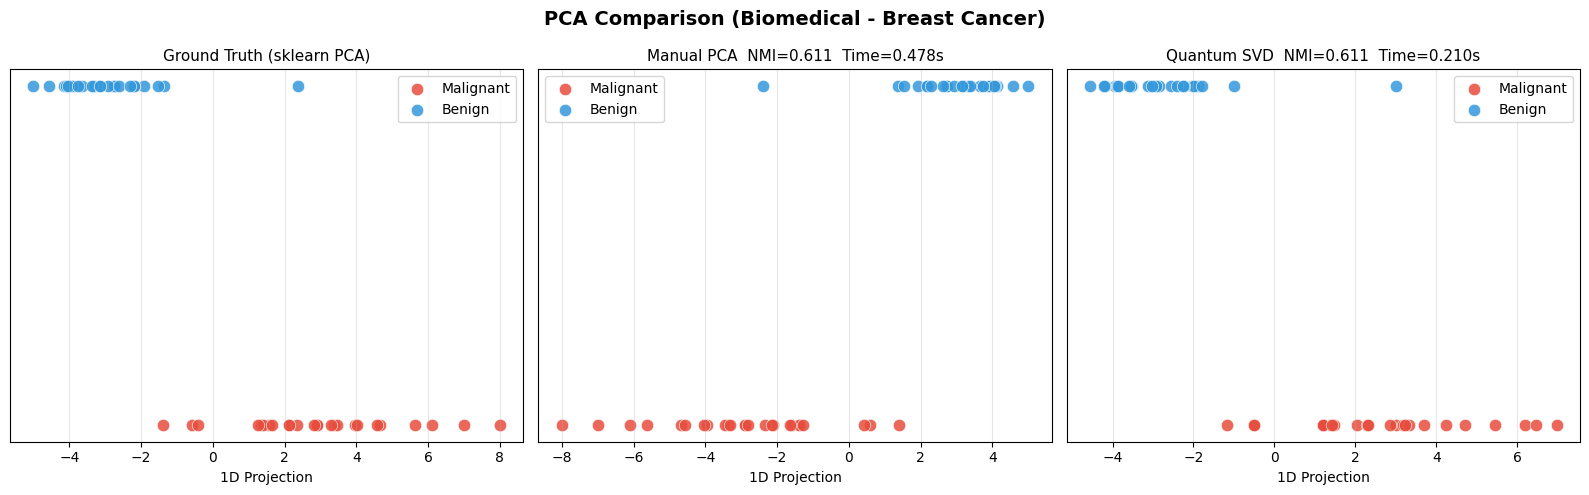

Saved: results/algo5_pca_comparison.png


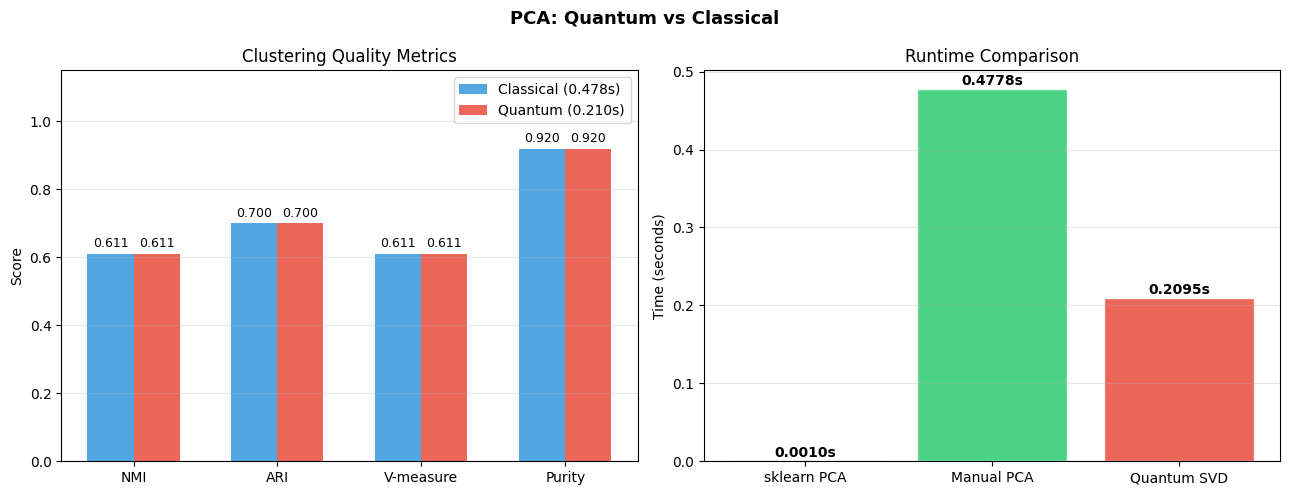

Saved: results/algo5_pca_metrics.png


In [47]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("PCA Comparison (Biomedical - Breast Cancer)", fontsize=14, fontweight="bold")

colors = ["#E74C3C", "#3498DB"]
label_names = ["Malignant", "Benign"]

for ax, (data_1d, labels_plot, title) in zip(axes, [
    (X_pca_sklearn[:, 0], y_sample, "Ground Truth (sklearn PCA)"),
    (X_pca_manual[:, 0],  y_sample, f"Manual PCA  NMI={nmi_man:.3f}  Time={time_manual:.3f}s"),
    (data_1d_qsvd,        y_sample, f"Quantum SVD  NMI={nmi_q:.3f}  Time={time_quantum:.3f}s"),
]):
    for c in range(2):
        idx_c = y_sample == c
        ax.scatter(data_1d[idx_c], np.zeros(idx_c.sum()) + c * 0.1,
                   c=colors[c], label=label_names[c], alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("1D Projection")
    ax.set_yticks([])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/algo5_pca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo5_pca_comparison.png")

# Metrics bar chart
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("PCA: Quantum vs Classical", fontsize=13, fontweight="bold")

metric_names = ["NMI", "ARI", "V-measure", "Purity"]
vals_classical = [nmi_man, ari_man, vm_man, pur_man]
vals_quantum_m = [nmi_q,   ari_q,   vm_q,   pur_q]

x = np.arange(len(metric_names))
width = 0.32
b1 = axes2[0].bar(x - width/2, vals_classical, width, label=f"Classical ({time_manual:.3f}s)", color="#3498DB", alpha=0.85)
b2 = axes2[0].bar(x + width/2, vals_quantum_m, width, label=f"Quantum ({time_quantum:.3f}s)",  color="#E74C3C", alpha=0.85)
for bar in list(b1) + list(b2):
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(metric_names)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_ylabel("Score")
axes2[0].set_title("Clustering Quality Metrics")
axes2[0].legend()
axes2[0].grid(True, axis="y", alpha=0.3)

methods = ["sklearn PCA", "Manual PCA", "Quantum SVD"]
times   = [time_spectral, time_manual, time_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes2[1].set_ylabel("Time (seconds)")
axes2[1].set_title("Runtime Comparison")
axes2[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/algo5_pca_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo5_pca_metrics.png")